# Machine Learning Classification Project

**Name:** LAVINIA MARIA ALEXANDRA SKANDALI

**Student ID:** 3305682

The goal of this notebook is to compare two classifiers, a Linear SVM and a 
Random Forest, on a dataset of 1500 samples with 5 possible class labels, and 
determine which works better. The dataset includes numeric and categorical features, 
missing values, and a hidden test set for final predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, RandomizedSearchCV,
                                     validation_curve, cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (make_scorer, f1_score, classification_report,
                             ConfusionMatrixDisplay)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('mldata_0003305682.csv')
print(df.shape)
df.head()

(1500, 30)


,id,label,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,categorical_feature_1,categorical_feature_2,categorical_feature_3
0,0,2,1.834491,-0.371199,-0.309159,-0.016084,0.606089,2.332601,1.538482,0.765845,...,0.150579,-0.081831,-1.169746,-0.248318,0.787263,-1.000835,0.269619,B,B,A
1,1,3,NaN,0.393643,-0.012786,0.192754,0.214464,4.659629,-0.216554,0.749402,...,-0.214175,-0.360848,-1.965588,0.068025,-0.506244,2.139566,0.262843,A,B,D
2,2,2,5.991127,0.568636,0.128588,-0.056321,0.730153,1.628646,0.426916,0.512812,...,-0.969383,-0.200402,-1.650081,0.023207,0.010743,-4.100195,1.395817,C,A,C
3,3,3,-0.020312,0.123957,-0.333875,0.048681,0.079292,-0.607713,1.442957,-0.815491,...,0.145291,-0.317451,-0.292886,0.420792,0.660101,1.155975,1.126640,B,D,NaN
4,4,2,4.104251,0.202791,-0.108393,-0.193023,0.082114,3.891586,0.348419,0.442500,...,-0.752399,-0.178395,-2.203988,-0.064645,0.007317,3.103652,1.019132,F,B,A


## 1. Exploratory Data Analysis

Before building any model, I inspected the dataset to understand its structure, 
identify potential issues, and inform preprocessing decisions. I looked at class 
balance, missing values, feature distributions, and correlations.

In [2]:
df.info()
print("\n")
df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1500 non-null   int64  
 1   label                  1500 non-null   int64  
 2   feature_1              1413 non-null   float64
 3   feature_2              1500 non-null   float64
 4   feature_3              1442 non-null   float64
 5   feature_4              1500 non-null   float64
 6   feature_5              1500 non-null   float64
 7   feature_6              1500 non-null   float64
 8   feature_7              1500 non-null   float64
 9   feature_8              1500 non-null   float64
 10  feature_9              1340 non-null   float64
 11  feature_10             1387 non-null   float64
 12  feature_11             1500 non-null   float64
 13  feature_12             1500 non-null   float64
 14  feature_13             1500 non-null   float64
 15  feature_14     

,id,label,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25
count,1500.00,1500.00,1413.00,1500.00,1442.00,1500.00,1500.00,1500.00,1500.00,1500.00,...,1356.00,1500.00,1382.00,1500.00,1401.00,1500.00,1500.00,1500.00,1405.00,1500.00
mean,749.50,2.14,0.61,0.06,0.01,0.01,0.16,-0.34,0.12,0.08,...,-0.07,0.01,0.01,0.05,0.03,-0.11,0.02,0.03,0.29,-0.02
std,433.16,1.39,5.24,0.26,0.27,0.11,1.01,4.74,0.98,1.00,...,1.64,0.43,0.14,0.58,0.26,2.23,0.19,0.62,3.49,0.70
min,0.00,0.00,-18.60,-0.85,-1.15,-0.37,-3.05,-19.48,-3.09,-2.96,...,-6.35,-1.65,-0.39,-1.88,-0.74,-7.33,-0.61,-1.93,-13.10,-3.18
25%,374.75,1.00,-2.80,-0.12,-0.17,-0.07,-0.51,-3.52,-0.53,-0.62,...,-1.17,-0.26,-0.09,-0.31,-0.15,-1.64,-0.12,-0.36,-1.98,-0.50
50%,749.50,2.00,0.77,0.06,0.01,0.00,0.16,-0.33,0.11,0.06,...,-0.06,0.01,0.01,0.07,0.02,-0.13,0.02,0.06,0.31,-0.03
75%,1124.25,3.00,4.11,0.23,0.19,0.08,0.82,2.75,0.79,0.75,...,1.03,0.29,0.10,0.44,0.21,1.40,0.14,0.48,2.63,0.45
max,1499.00,4.00,15.32,0.92,0.84,0.40,3.36,14.30,3.19,3.46,...,5.21,1.43,0.48,1.92,0.93,6.75,0.61,2.10,10.87,2.39


The dataset contains 1500 samples and 30 columns: one ID column, one label column, 
25 numeric features, and 3 categorical features. Several columns contain missing 
values (8 numeric and 2 categorical) which will need to be addressed in 
preprocessing. Most numeric features appear centred near zero with similar scales, 
though some exceptions (notably `feature_6`, `feature_10`) show much wider ranges, 
confirming that standardisation will be necessary.

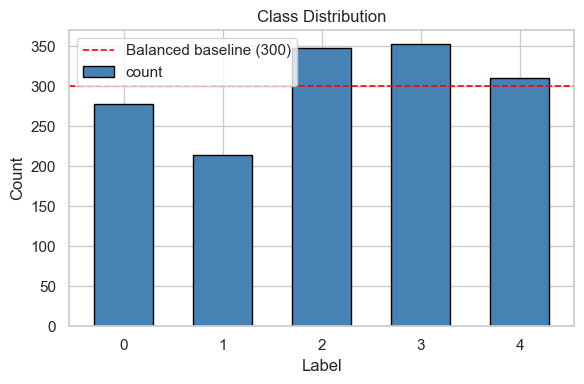

label
0    277
1    214
2    347
3    352
4    310
Name: count, dtype: int64


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['label'].value_counts().sort_index()
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', width=0.6)
ax.axhline(1500/5, color='red', linestyle='--', linewidth=1.2, label='Balanced baseline (300)')
ax.set_title('Class Distribution')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend()
plt.tight_layout()
plt.show()
print(counts)

The classes are mildly imbalanced. Label 1 is the least frequent (214 samples, ~14%) 
and label 3 the most frequent (352, ~23%), giving a majority-to-minority ratio of 
roughly 1.6×. This is not severe enough to require resampling, but it has two 
implications: (1) **macro-averaged F1** is a more appropriate metric than accuracy, 
since it weights all classes equally regardless of frequency; (2) both models will 
be trained with `class_weight='balanced'` to avoid bias toward majority classes.

                       Missing count  Missing %
categorical_feature_3            241       16.1
feature_9                        160       10.7
feature_16                       144        9.6
feature_18                       118        7.9
categorical_feature_2            118        7.9
feature_10                       113        7.5
feature_20                        99        6.6
feature_24                        95        6.3
feature_1                         87        5.8
feature_3                         58        3.9


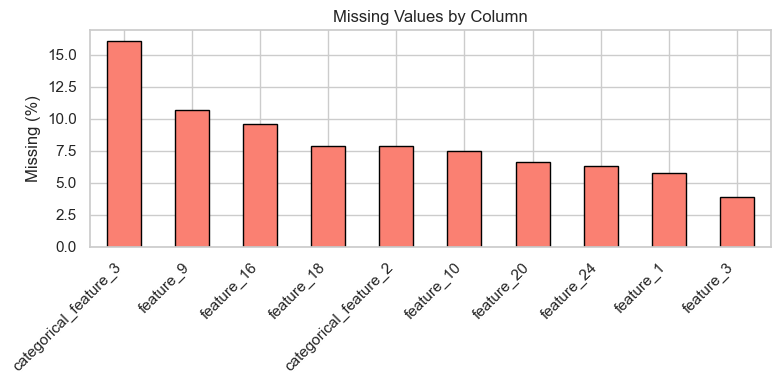

In [4]:
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing count': miss, 'Missing %': miss_pct})
print(miss_df)

fig, ax = plt.subplots(figsize=(8, 4))
miss_pct.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
ax.set_title('Missing Values by Column')
ax.set_ylabel('Missing (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

Missing rate for feature_9 per class:
label
0    0.126
1    0.098
2    0.110
3    0.105
4    0.094
Name: f9_missing, dtype: float64


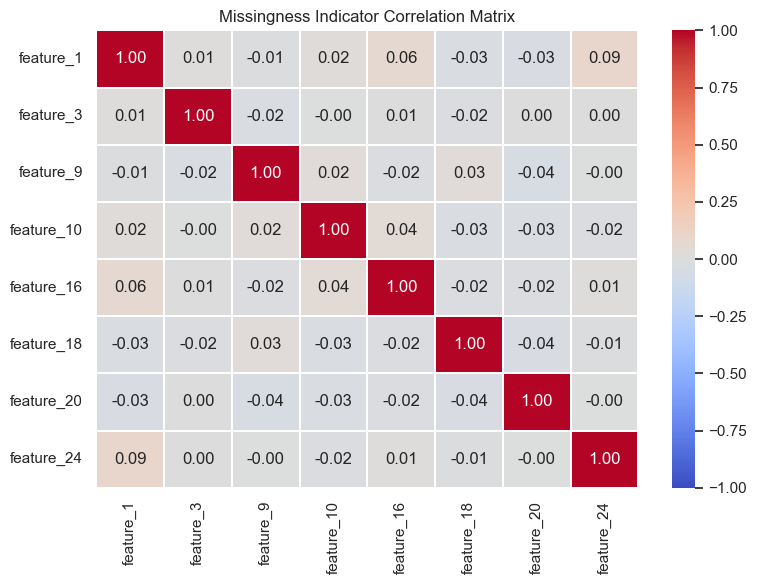

In [5]:
df['f9_missing'] = df['feature_9'].isnull().astype(int)
print('Missing rate for feature_9 per class:')
print(df.groupby('label')['f9_missing'].mean().round(3))
df.drop(columns=['f9_missing'], inplace=True)

miss_cols = ['feature_1','feature_3','feature_9','feature_10',
             'feature_16','feature_18','feature_20','feature_24']
miss_corr = df[miss_cols].isnull().astype(int).corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(miss_corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', ax=ax, linewidths=0.3)
ax.set_title('Missingness Indicator Correlation Matrix')
plt.tight_layout()
plt.show()

Ten columns have missing values, eight numeric and two categorical. The worst is 
`categorical_feature_3` at 16.1%, and `feature_9` at 10.7%. The rest are all under 
10%, which is manageable.

To assess whether the missingness is informative, I checked two things. First, 
whether missing rates differ across class labels, for `feature_9`, the missing 
rate ranges from 9.4% to 12.6% across the five classes, which is not meaningfully 
different. Second, I computed pairwise correlations between missingness indicators 
across all affected columns. The heatmap above shows all correlations are very 
close to zero (max ~0.09), confirming no strong co-missingness pattern. Together 
these suggest the data is approximately **Missing Completely At Random (MCAR)**, 
making simple imputation appropriate.

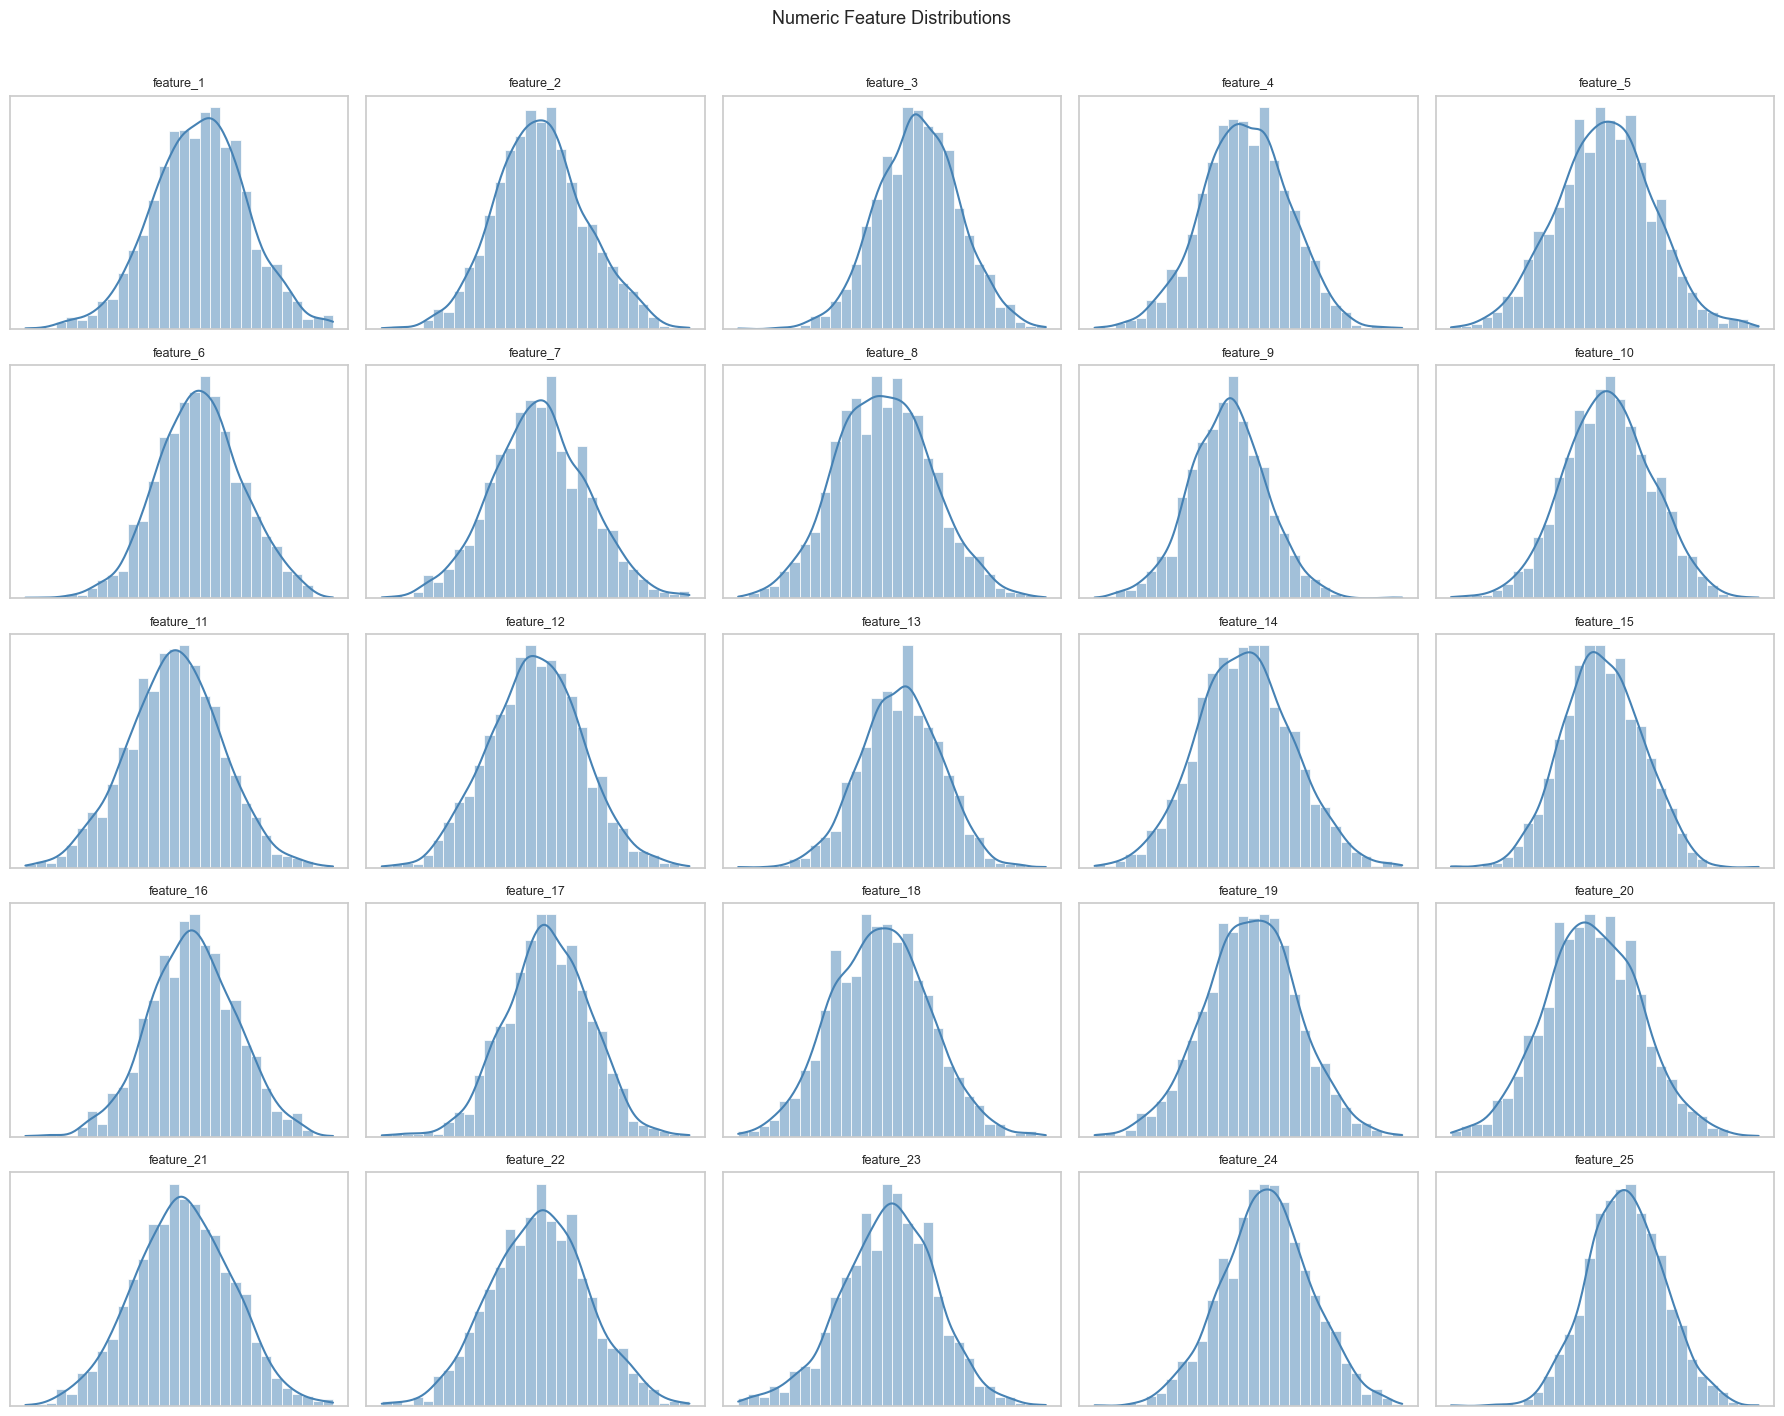

In [6]:
num_cols = [f'feature_{i}' for i in range(1, 26)]

fig, axes = plt.subplots(5, 5, figsize=(18, 14))
for i, col in enumerate(num_cols):
    ax = axes[i//5][i%5]
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax,
                 color='steelblue', line_kws={'linewidth': 1.5, 'color': 'darkblue'})
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.suptitle('Numeric Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Most features look roughly normally distributed and centred near zero, which is 
reassuring. The shapes are fairly similar across the board, though some features 
like `feature_6` and `feature_10` are noticeably wider than others, meaning their 
values span a much larger range. This is exactly why standardisation is needed before 
feeding the data into LinearSVC, which is sensitive to the scale of features. Without 
it, wider features would unfairly dominate the model.

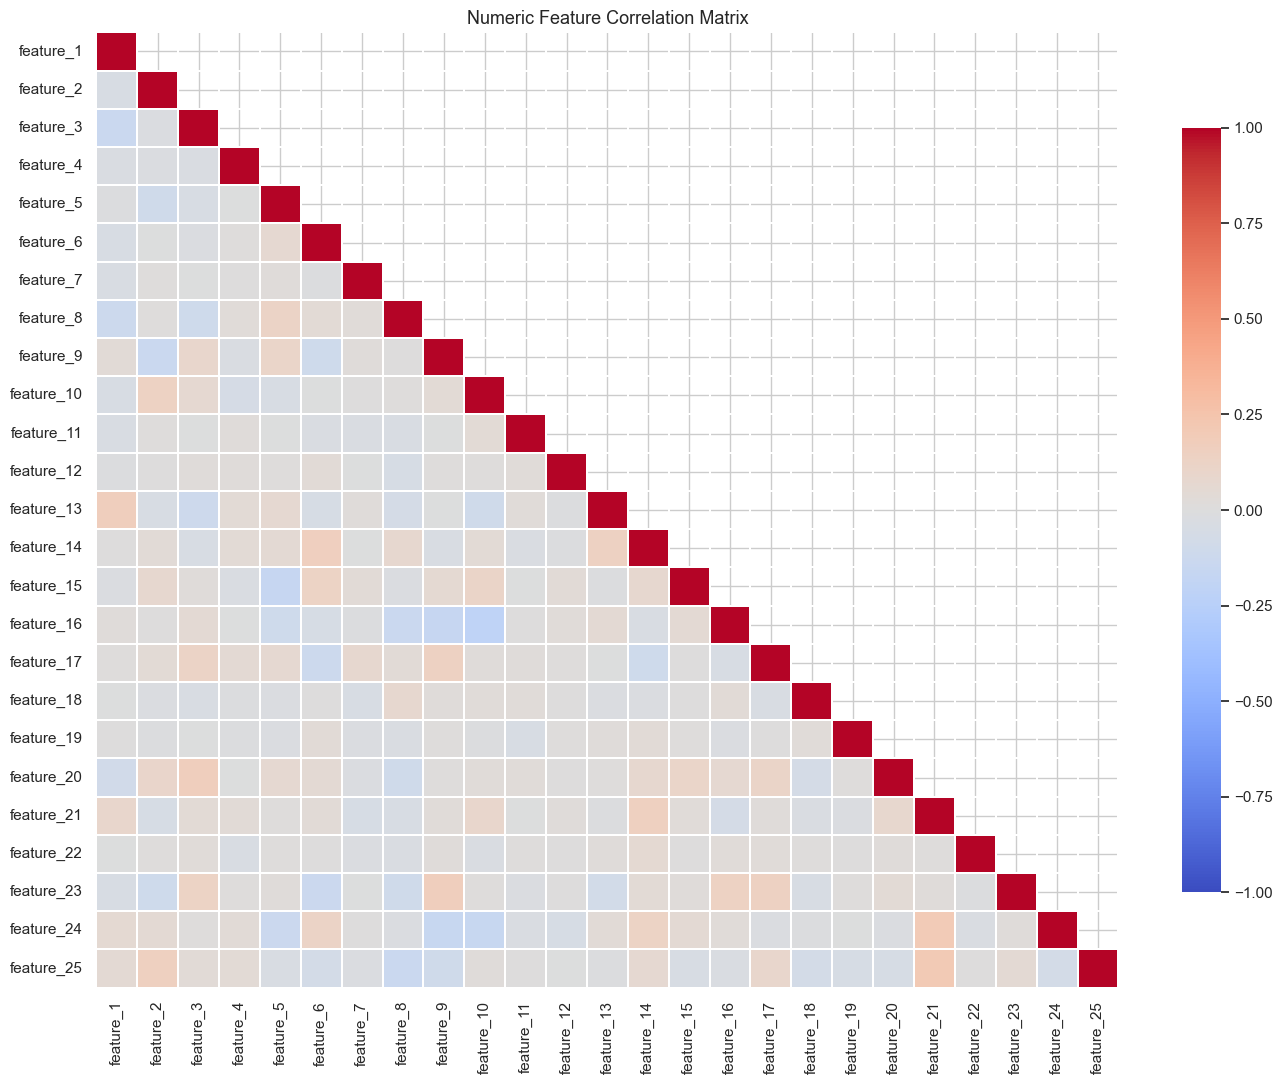

In [7]:
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            cbar_kws={'shrink': 0.8})
ax.set_title('Numeric Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

The heatmap shows that most pairwise Pearson correlations between numeric features 
are small, with no pair exceeding 0.21 in absolute value. This suggests limited 
linear multicollinearity among the features, which supports keeping all 25 initially. 
However, low pairwise correlation does not rule out nonlinear relationships or 
higher-order interactions between features. This plot should therefore be interpreted 
as evidence against strong linear redundancy rather than proof that dimensionality 
reduction would provide no benefit

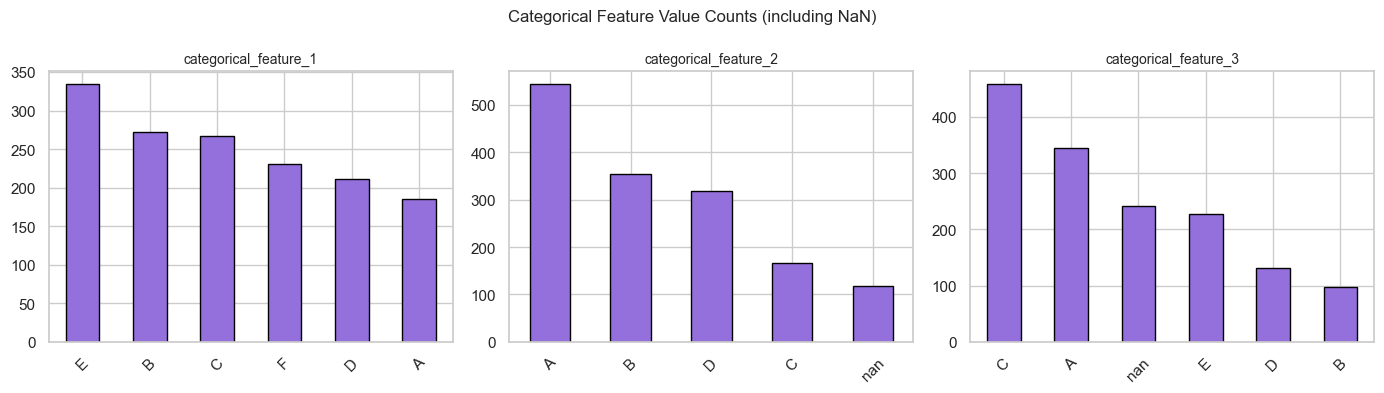

In [8]:
cat_cols = ['categorical_feature_1', 'categorical_feature_2', 'categorical_feature_3']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=ax,
                                             edgecolor='black', color='mediumpurple')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Categorical Feature Value Counts (including NaN)', fontsize=12)
plt.tight_layout()
plt.show()

All three categorical features contain unordered nominal values, making one-hot 
encoding the appropriate choice. `categorical_feature_1` has no missing values and 
is relatively balanced across its 6 categories. `categorical_feature_2` and 
`categorical_feature_3` both contain missing values, with the latter showing notable 
imbalance. Category C accounts for nearly half of all non-missing observations, 
while category B has under 100.

## 2. Preprocessing

Before fitting any model, the raw features need to be cleaned and transformed. 
Numeric and categorical features require different treatment, so I used a 
`ColumnTransformer` to apply separate pipelines to each. Everything is wrapped 
in a single `Pipeline` object to ensure no information from the test set leaks 
into the training process.

In [9]:
X = df.drop(columns=['id', 'label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'\nClass distribution in training set:')
print(y_train.value_counts().sort_index())
print(f'\nClass distribution in test set:')
print(y_test.value_counts().sort_index())

Training set: (1200, 28)
Test set:     (300, 28)

Class distribution in training set:
label
0    221
1    171
2    278
3    282
4    248
Name: count, dtype: int64

Class distribution in test set:
label
0    56
1    43
2    69
3    70
4    62
Name: count, dtype: int64


The data is split into 80% training (1200 samples) and 20% test (300 samples). 
Using `stratify=y` ensures the class proportions are preserved in both sets, which 
is important given the mild imbalance. The test set is only touched once at the very 
end to report final performance — all model selection and hyperparameter tuning is 
done exclusively on the training set.

In [10]:
num_features = [f'feature_{i}' for i in range(1, 26)]
cat_features = ['categorical_feature_1', 'categorical_feature_2', 'categorical_feature_3']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

print('Preprocessor built successfully')

Preprocessor built successfully


The numeric pipeline applies median imputation followed by standard scaling. The 
categorical pipeline applies mode imputation followed by one-hot encoding, with 
`handle_unknown='ignore'` to safely handle any categories in the test set that 
were not seen during training. Wrapping everything in a `ColumnTransformer` ensures 
the correct transformations are applied to the correct columns automatically.

## 3. Validation Strategy

With the preprocessing pipeline in place, I then defined how models will be evaluated. 
The choice of validation strategy and scoring metric directly affects which model 
gets selected, so it is worth being explicit about both decisions.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scorer = make_scorer(f1_score, average='macro')

print('Cross-validation: Stratified 5-fold')
print('Scoring metric: Macro-averaged F1')

Cross-validation: Stratified 5-fold
Scoring metric: Macro-averaged F1


Stratified 5-fold cross-validation is used throughout, which preserves class 
proportions in each fold. This is preferable to standard k-fold when classes are 
imbalanced, as it ensures every fold is representative of the full dataset.

Macro-averaged F1 is chosen as the primary metric rather than accuracy. Since F1 
is computed per class and then averaged equally across all five classes, it penalises 
poor performance on minority classes like label 1 just as much as on majority classes. 
Accuracy would be misleading here since a model could score reasonably well by simply 
performing better on the more frequent labels.

## 4. Model Comparison and Hyperparameter Tuning

I built and tuned two models, a Linear Support Vector Machine 
(`LinearSVC`) and a Random Forest (`RandomForestClassifier`). Each is wrapped in 
a full pipeline with the preprocessor defined above. Hyperparameters are tuned 
using cross-validated search, and the two best models are then compared directly.

### 4.0 Dummy Baseline

Before tuning any real model, I established a baseline using a majority-class 
classifier, which gives context to all subsequent scores.

In [12]:
from sklearn.dummy import DummyClassifier

dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DummyClassifier(strategy='most_frequent'))
])

dummy_cv = cross_validate(dummy, X_train, y_train, cv=cv, scoring=scorer)
print(f'Dummy classifier CV macro F1: {dummy_cv["test_score"].mean():.4f}')

Dummy classifier CV macro F1: 0.0761


The majority-class baseline achieves a macro F1 of 0.0761, since it predicts 
only the most frequent label and scores zero on all other classes. This 
confirms that both LinearSVC (0.4674) and Random Forest (0.6005) are learning 
genuine structure from the data rather than exploiting class imbalance, with 
Random Forest scoring nearly eight times higher than the baseline.

### 4.1 Linear Support Vector Machine

The key hyperparameter for LinearSVC is `C`, which controls the trade-off between 
maximising the margin and minimising classification errors. A smaller `C` means more 
regularisation, a larger `C` means the model tries harder to classify every training 
point correctly. I searched over a logarithmically spaced grid of 6 values to identify 
the right order of magnitude.

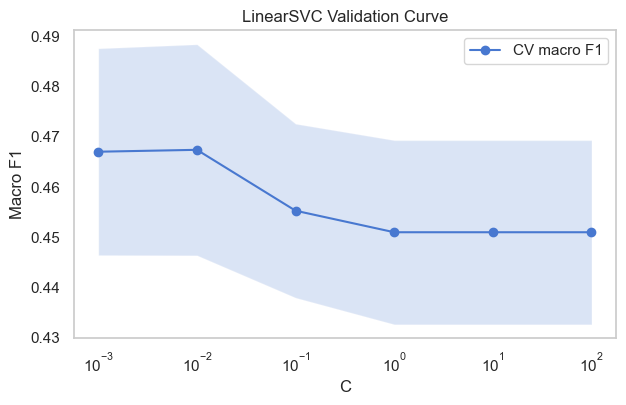

In [13]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LinearSVC(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
])

C_range = [0.001, 0.01, 0.1, 1, 10, 100]

train_scores, val_scores = validation_curve(
    svm_pipeline, X_train, y_train,
    param_name='clf__C', param_range=C_range,
    cv=cv, scoring=scorer, n_jobs=-1
)

plt.figure(figsize=(7, 4))
plt.semilogx(C_range, val_scores.mean(axis=1), 'o-', label='CV macro F1')
plt.fill_between(C_range,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
plt.xlabel('C')
plt.ylabel('Macro F1')
plt.title('LinearSVC Validation Curve')
plt.legend()
plt.grid()
plt.show()

The validation curve shows that performance decreases as C increases, meaning 
stronger regularisation works better for this dataset. The curve plateaus around 
C=0.001 and C=0.01, both achieving a macro F1 of approximately 0.467. Beyond that, 
performance drops and stabilises at a lower value. This suggests the decision 
boundary for this problem benefits from a wider margin rather than trying to fit 
the training data more closely.

In [14]:
svm_param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

svm_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    verbose=1
)

svm_search.fit(X_train, y_train)

print(f'Best C: {svm_search.best_params_}')
print(f'Best CV macro F1: {svm_search.best_score_:.4f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best C: {'clf__C': 0.01}
Best CV macro F1: 0.4674


Grid search confirms C=0.01 as the optimal value, consistent with the validation 
curve above. The best cross-validated macro F1 is 0.4674. This will be the 
LinearSVC configuration used in the final model comparison.

### 4.2 Random Forest

Random Forest has several hyperparameters worth tuning. Rather than searching all 
of them simultaneously, I first used a validation curve to find a sensible value 
for `n_estimators`, the number of trees. Once the performance curve plateaus, 
adding more trees gives no further benefit. I then fixed `n_estimators` and used 
`RandomizedSearchCV` to search the remaining structural hyperparameters efficiently.

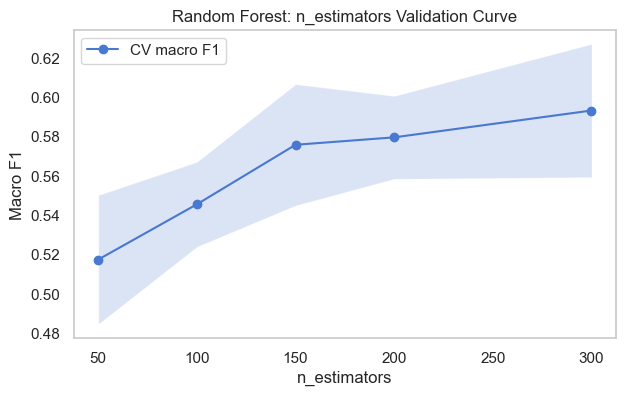

In [15]:
rf_base = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

n_est_range = [50, 100, 150, 200, 300]

train_sc, val_sc = validation_curve(
    rf_base, X_train, y_train,
    param_name='clf__n_estimators', param_range=n_est_range,
    cv=cv, scoring=scorer, n_jobs=-1
)

plt.figure(figsize=(7, 4))
plt.plot(n_est_range, val_sc.mean(axis=1), 'o-', label='CV macro F1')
plt.fill_between(n_est_range,
                 val_sc.mean(axis=1) - val_sc.std(axis=1),
                 val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.2)
plt.xlabel('n_estimators')
plt.ylabel('Macro F1')
plt.title('Random Forest: n_estimators Validation Curve')
plt.legend()
plt.grid()
plt.show()

Performance improves steadily up to around 150 trees and begins to plateau beyond 
that, with only marginal gains from 200 to 300. I fixed `n_estimators=200` as a 
reasonable compromise between predictive performance and computation time. The 
remaining structural hyperparameters are tuned in the next step.
    

In [16]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

rf_param_dist = {
    'clf__max_depth':          [10, 20, 30, None],
    'clf__min_samples_split':  [2, 5, 10],
    'clf__min_samples_leaf':   [1, 2, 4],
    'clf__max_features':       ['sqrt', 'log2', 0.3],
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_dist,
    n_iter=40,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f'Best RF params: {rf_search.best_params_}')
print(f'Best CV macro F1: {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RF params: {'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.3, 'clf__max_depth': 20}
Best CV macro F1: 0.6038


The expanded randomised search (n_iter=40) identifies `max_depth=20`, `max_features=0.3`, 
`min_samples_leaf=1`, and `min_samples_split=2` as the best combination, achieving a 
cross-validated macro F1 of 0.6038. A shallower tree depth (20 vs the previous 
30) performs better, suggesting the deeper trees were overfitting slightly. Adding 
`min_samples_leaf` to the search space allowed the model to find a better regularised 
configuration than before.

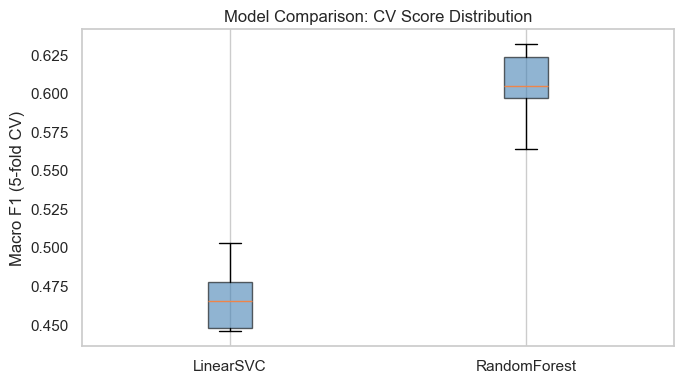

LinearSVC    mean: 0.4674  std: 0.0211
RandomForest mean: 0.6038  std: 0.0238


In [17]:
svm_cv = cross_validate(svm_search.best_estimator_, X_train, y_train, cv=cv, scoring=scorer)
rf_cv  = cross_validate(rf_search.best_estimator_,  X_train, y_train, cv=cv, scoring=scorer)

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([svm_cv['test_score'], rf_cv['test_score']],
           tick_labels=['LinearSVC', 'RandomForest'], patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Macro F1 (5-fold CV)')
ax.set_title('Model Comparison: CV Score Distribution')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

svm_mean = svm_cv['test_score'].mean()
svm_std  = svm_cv['test_score'].std()
rf_mean  = rf_cv['test_score'].mean()
rf_std   = rf_cv['test_score'].std()

print(f'LinearSVC    mean: {svm_mean:.4f}  std: {svm_std:.4f}')
print(f'RandomForest mean: {rf_mean:.4f}  std: {rf_std:.4f}')

Random Forest achieves a mean macro F1 of 0.6038 (std 0.0238) against LinearSVC's 0.4674 
(std 0.0211). The two boxes do not overlap at all, indicating the difference is consistent 
across all five folds rather than being driven by a single lucky split. The standard 
deviation for Random Forest dropped from 0.0364 to 0.0238 with the expanded search, 
suggesting the new configuration is more stable across folds. Random Forest is the stronger 
model for this dataset.

## 5. Final Model

Having established that Random Forest outperforms LinearSVC, I retrained the best 
Random Forest configuration on the full training set and evaluated it once on the 
held-out test set. This is the only time the test set is used.

              precision    recall  f1-score   support

           0      0.600     0.536     0.566        56
           1      0.704     0.442     0.543        43
           2      0.588     0.681     0.631        69
           3      0.598     0.700     0.645        70
           4      0.656     0.645     0.650        62

    accuracy                          0.617       300
   macro avg      0.629     0.601     0.607       300
weighted avg      0.623     0.617     0.613       300

Test macro F1: 0.6070


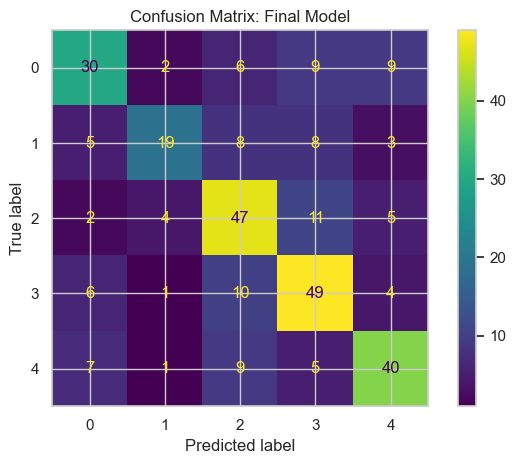

In [18]:
final_model = rf_search.best_estimator_
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))
print(f'Test macro F1: {f1_score(y_test, y_pred, average="macro"):.4f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix: Final Model')
plt.tight_layout()
plt.show()

The final model achieves a macro F1 of 0.607 on the held-out test set, close to 
the cross-validated estimate of 0.6038, confirming the model generalises well and 
was not overfit during tuning.

Looking at performance per class, labels 2, 3 and 4 are the strongest with F1 
scores of 0.631, 0.645 and 0.650 respectively. Label 1 is the weakest at 0.543, 
though this is a meaningful improvement over the previous configuration (0.493), 
and is expected given it is the least represented class in the training data with 
only 171 samples. Label 0 sits in the middle at 0.566.

A notable pattern is that label 1 has high precision (0.704) but low recall (0.442), 
meaning the model is conservative about predicting label 1. When it does predict 
it, it is usually correct, but it misses many true label 1 samples, likely 
classifying them as labels 0 or 2 instead. This is consistent with the class 
imbalance and suggests that further oversampling of label 1 or a lower 
classification threshold could improve recall for this class.

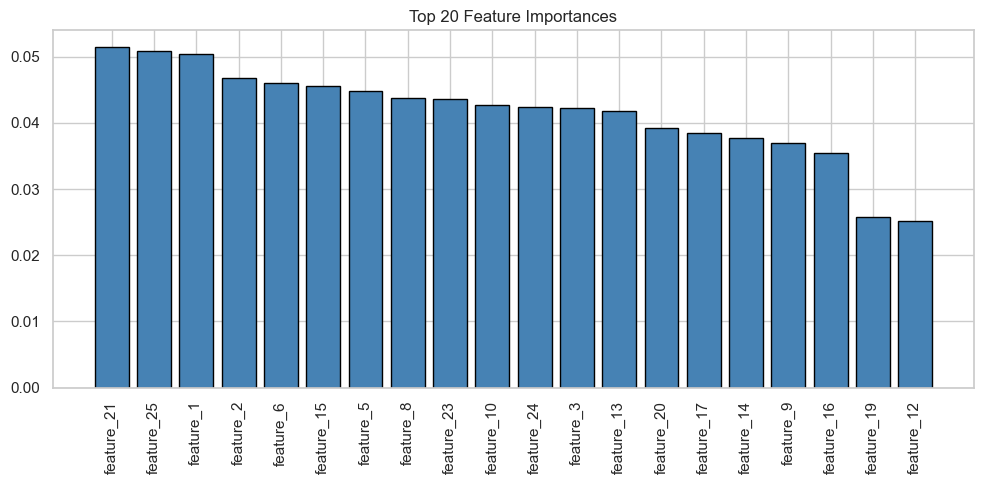

In [19]:
ohe_cats = final_model.named_steps['preprocessor']\
               .named_transformers_['cat']['encoder']\
               .get_feature_names_out(cat_features)
feature_names = num_features + list(ohe_cats)

importances = final_model.named_steps['clf'].feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10, 5))
plt.bar(range(20), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=90)
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

The top 20 features are all numeric, with `feature_25` and `feature_1` marginally 
ahead of the rest. Notably, the importances are very evenly distributed. No single 
feature dominates, with values ranging only from roughly 0.024 to 0.055. This is 
consistent with the low inter-feature correlations observed earlier and helps explain 
why the model benefits from keeping all features rather than doing any selection or 
dimensionality reduction. The categorical features do not appear in the top 20, 
suggesting they contribute relatively little predictive information compared to the 
numeric features.

### Learning Curve

To assess whether the final model is overfitting or underfitting, I plotted the 
learning curve, showing how training and cross-validation performance change 
as more training data is used.

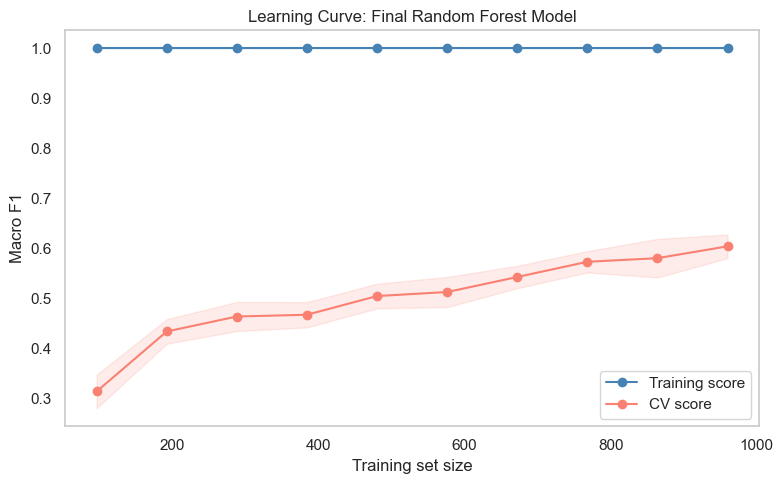

In [20]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    final_model,
    X_train, y_train,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', color='salmon', label='CV score')
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.15, color='steelblue')
plt.fill_between(train_sizes, val_mean - val_std,
                 val_mean + val_std, alpha=0.15, color='salmon')
plt.xlabel('Training set size')
plt.ylabel('Macro F1')
plt.title('Learning Curve: Final Random Forest Model')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

The training score sits at 1.0 throughout, which is characteristic of deep 
decision trees. Random Forest memorises the training data almost perfectly 
regardless of size. The more informative line is the CV score, which starts 
low with little data and rises steadily to around 0.60, without showing signs 
of plateauing. This tells us that the model is genuinely learning 
signal from the data rather than just memorising noise, and performance would 
likely continue to improve with a larger dataset. The gap between training and 
CV score is large but expected for an unconstrained Random Forest. It could 
be reduced by restricting `max_depth` more aggressively, though this would 
trade some predictive performance for lower variance.

## 6. Test Predictions

With the final model trained, I generated predictions on the hidden test set. 
This was done using the same pipeline, so all preprocessing steps are applied 
automatically and consistently.

In [21]:
df_test = pd.read_csv('mldata_0003305682.TEST_FEATURES.csv')
X_test_hidden = df_test.drop(columns=['id'])

test_preds = final_model.predict(X_test_hidden)

np.savetxt('mldata_0003305682_predictions.txt', test_preds, fmt='%d')
print(f'Saved {len(test_preds)} predictions')
print('\nPrediction distribution:')
print(pd.Series(test_preds).value_counts().sort_index())

Saved 1500 predictions

Prediction distribution:
0    243
1     85
2    431
3    400
4    341
Name: count, dtype: int64


Predictions were generated for all 1500 test samples using the final Random Forest 
pipeline. The predicted class distribution is broadly consistent with the training 
set distribution, with label 1 remaining the least frequent prediction. The 
predictions are saved to `mldata_0003305682_predictions.txt`, one integer label 
per line with no header, as required.

## 7. Conclusions

The analysis compared a Linear Support Vector Machine and a Random Forest classifier 
on a tabular 5-class classification dataset with missing values, categorical features, 
and mild class imbalance.

Random Forest was the stronger model by a considerable margin, achieving a 
cross-validated macro F1 of 0.6038 compared to 0.4674 for LinearSVC. The gap 
was consistent across all five folds, indicating the result is robust rather 
than driven by a fortunate split. LinearSVC assumes a linear decision boundary 
in the feature space, meaning it can only separate classes with a flat 
hyperplane. Given that the dataset has 25 numeric features with no strong 
correlations and no obvious linear structure, this assumption is too restrictive. 
Random Forest, by contrast, builds an ensemble of decision trees that can capture 
complex non-linear interactions between features, making it inherently better 
suited to this kind of data. The learning curve further confirms this — the model 
is genuinely learning from the data and performance continues to improve with 
training size.

The final model used `n_estimators=200`, `max_depth=20`, `max_features=0.3`, 
`min_samples_leaf=1`, `min_samples_split=2`, and `class_weight='balanced'`, 
achieving a test set macro F1 of 0.607.

Preprocessing choices were informed directly by the EDA. Median imputation was 
preferred over mean for numeric features due to the wide-range outliers observed in 
several columns, and mode imputation was used for categorical features. Standard 
scaling was applied to all numeric features, which is essential for LinearSVC and 
consistent practice for Random Forest. All steps were encapsulated in a single 
sklearn Pipeline to prevent data leakage.

Several limitations are worth noting. The MCAR assumption for missing data was not 
formally tested, and more sophisticated imputation strategies such as KNN or 
iterative imputation could potentially improve performance. The hyperparameter search 
was intentionally budget-constrained, and a broader search might yield modest further 
gains. The relatively even spread of feature importances also suggests the dataset 
may benefit from feature engineering, though this was beyond the scope of the 
mandatory task.

## 8. LLM Audit

As required, I prompted a large language model with the suggested prompt from the 
project instructions and compared its proposed workflow with the one implemented 
in this notebook.

The LLM proposed a broadly sound workflow. It correctly identified the need for a 
`Pipeline` and `ColumnTransformer` to prevent data leakage, suggested stratified 
k-fold cross-validation, recommended median imputation for numeric features and 
mode imputation for categorical ones, and used macro F1 as the primary metric, 
all consistent with the approach taken in this notebook.

There are however some notable differences and questionable choices. First, the LLM 
suggested comparing four models including a dummy baseline and a 
`HistGradientBoostingClassifier`, neither of which were required by the project 
brief. While testing more models is not inherently wrong, it risks becoming unfocused 
and the project instructions explicitly asked for a comparison between LinearSVC and 
Random Forest specifically. Second, the LLM's hyperparameter search used `n_iter=40` 
with a wide continuous distribution for `n_estimators` (200 to 800) without first 
using a validation curve to identify a sensible range, which is a less principled approach 
than the one taken here, where `n_estimators` was fixed first via a validation curve 
before tuning the remaining parameters. Third, the LLM added `add_indicator=True` 
to the numeric imputer, which creates binary columns flagging where values were 
missing. This could be useful if missingness is informative, but as established in 
the EDA above, missingness in this dataset is approximately MCAR, making this 
addition unnecessary and potentially adding noise. Finally, the LLM included ROC-AUC 
as a metric but noted it applies only to binary classification. This dataset has 
five classes, so that section of its suggested code would not be applicable here 
without modification.

Overall, the LLM suggestion is reasonable as a generic starting point but lacks the 
dataset-specific reasoning that comes from actually examining the data first. The 
choices made in this notebook were informed directly by the EDA findings rather than 
applied as defaults.